# Sales Figures Predict

### How much will my sales figures increase if I invest in TV, radio and newspaper separately?

#### Import necessary packages

In [64]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")
pd.set_option("display.max_columns",100)
pd.set_option('display.float_format', '{:.6f}'.format)

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

In [6]:
df=pd.read_csv("advertising.csv")

In [10]:
### EDA - Exploratory Data Analysis

In [8]:
df.head()

,TV,Radio,Newspaper,Sales
0,230.100000,37.800000,69.200000,22.100000
1,44.500000,39.300000,45.100000,10.400000
2,17.200000,45.900000,69.300000,9.300000
3,151.500000,41.300000,58.500000,18.500000
4,180.800000,10.800000,58.400000,12.900000


In [12]:
df.tail()

,TV,Radio,Newspaper,Sales
195,38.200000,3.700000,13.800000,7.600000
196,94.200000,4.900000,8.100000,9.700000
197,177.000000,9.300000,6.400000,12.800000
198,283.600000,42.000000,66.200000,25.500000
199,232.100000,8.600000,8.700000,13.400000


In [14]:
df.sample(3)

,TV,Radio,Newspaper,Sales
144,96.200000,14.800000,38.900000,11.400000
182,56.200000,5.700000,29.700000,8.700000
149,44.700000,25.800000,20.600000,10.100000


In [16]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
TV,200.000000,147.042500,85.854236,0.700000,74.375000,149.750000,218.825000,296.400000
Radio,200.000000,23.264000,14.846809,0.000000,9.975000,22.900000,36.525000,49.600000
Newspaper,200.000000,30.554000,21.778621,0.300000,12.750000,25.750000,45.100000,114.000000
Sales,200.000000,14.022500,5.217457,1.600000,10.375000,12.900000,17.400000,27.000000


In [20]:
df.shape

(200, 4)

In [22]:
df.corr(numeric_only=True)

,TV,Radio,Newspaper,Sales
TV,1.000000,0.054809,0.056648,0.782224
Radio,0.054809,1.000000,0.354104,0.576223
Newspaper,0.056648,0.354104,1.000000,0.228299
Sales,0.782224,0.576223,0.228299,1.000000


<Axes: >

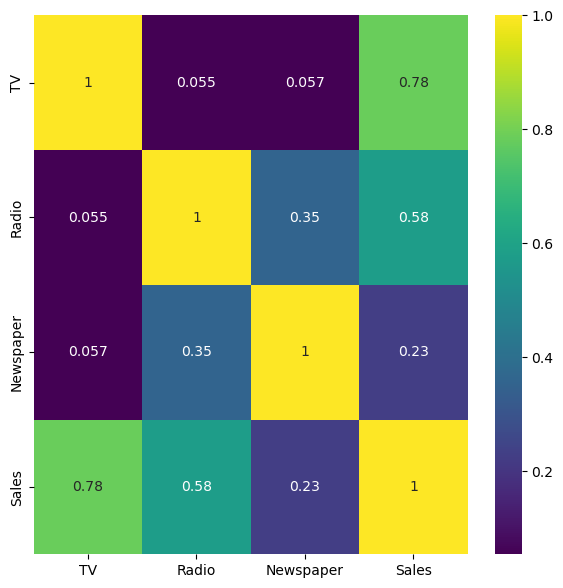

In [38]:
plt.figure(figsize=(7,7))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="viridis")

In [43]:
abs(df.corr(numeric_only=True)["Sales"].sort_values(ascending=False))

Sales       1.000000
TV          0.782224
Radio       0.576223
Newspaper   0.228299
Name: Sales, dtype: float64

<Axes: xlabel='TV'>

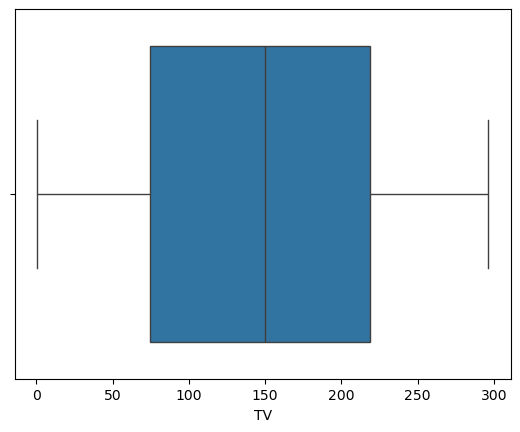

In [47]:
sns.boxplot(x=df["TV"])

<Axes: xlabel='Radio'>

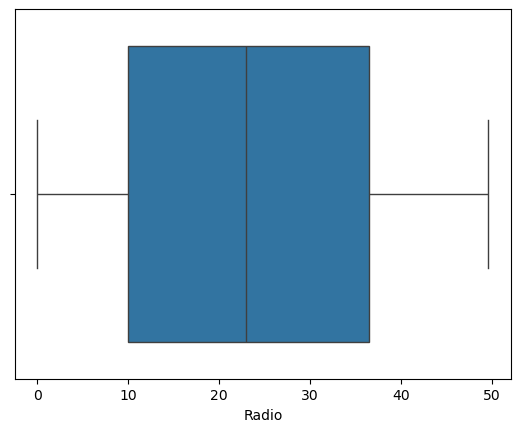

In [49]:
sns.boxplot(x=df["Radio"])

<Axes: xlabel='Newspaper'>

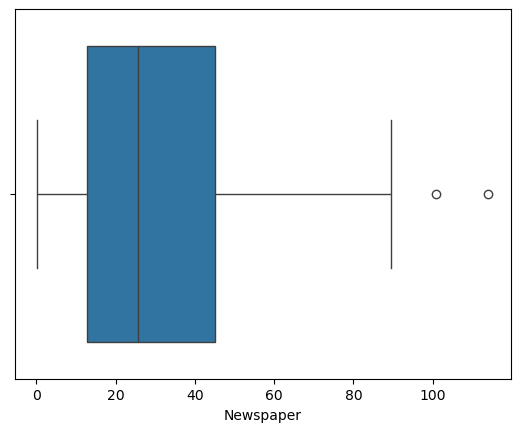

In [51]:
sns.boxplot(x=df["Newspaper"])

##### Outlier 

In [54]:
outliers=df.quantile(q=.97, numeric_only=True)

In [58]:
df=df[(df['Newspaper']<outliers['Newspaper'])]

<Axes: xlabel='Newspaper'>

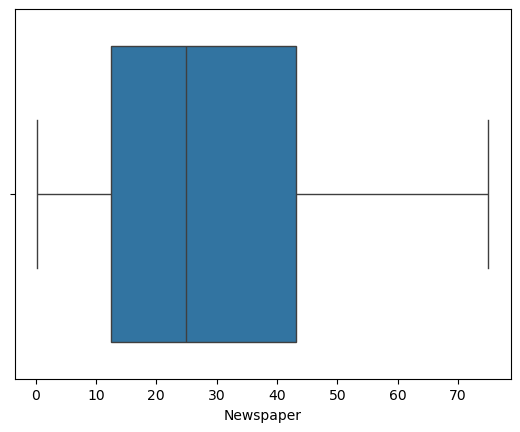

In [60]:
sns.boxplot(x=df["Newspaper"])

In [62]:
abs(df.corr(numeric_only=True)["Sales"].sort_values(ascending=False))

Sales       1.000000
TV          0.783089
Radio       0.586535
Newspaper   0.242819
Name: Sales, dtype: float64

In [71]:
x=df.drop(["Sales"], axis=1)
y=df[["Sales"]]

### Modelling

In [73]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=.20, random_state=42)

In [75]:
lr=LinearRegression()

In [77]:
lr.fit(x_train, y_train)

LinearRegression()

In [79]:
y_predict=lr.predict(x_test)

In [81]:
r2_score(y_test, y_predict)

0.8995263574958908

In [105]:
mean_squared_error(y_test, y_predict)**.5

1.6931269371410205

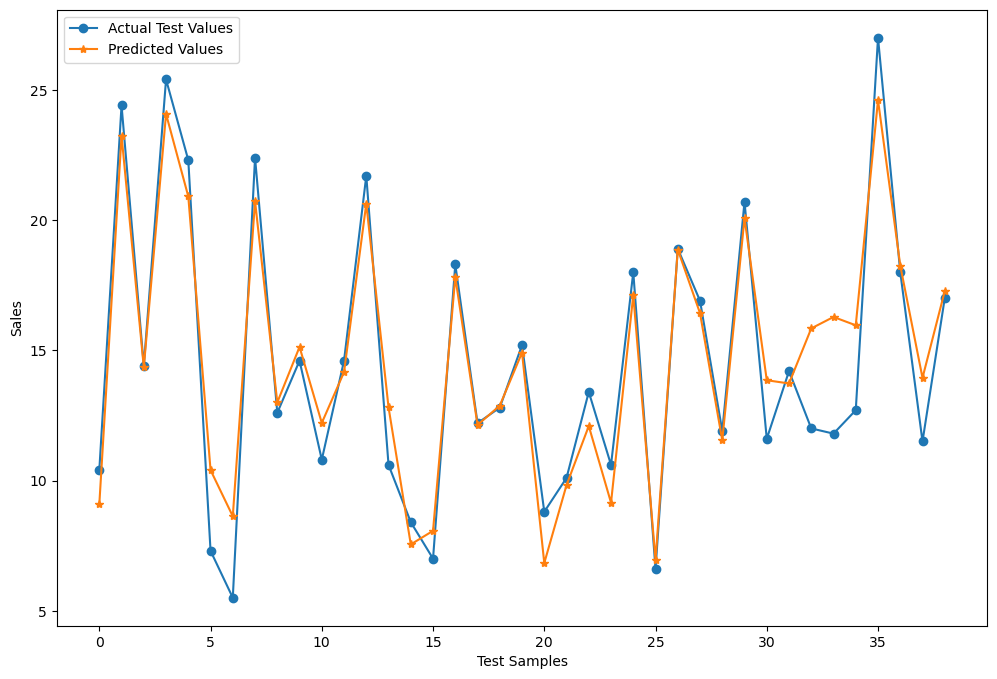

In [99]:
plt.figure(figsize=(12,8))
plt.plot(y_test.values, label='Actual Test Values', marker='o')
plt.plot(y_predict, label='Predicted Values', marker='*')
plt.xlabel("Test Samples")
plt.ylabel("Sales")
plt.legend()
plt.show()

### Bonus

In [108]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")
pd.set_option("display.max_columns",100)
pd.set_option('display.float_format', '{:.6f}'.format)

from sklearn.linear_model import LinearRegression,SGDRegressor,Ridge,Lasso,ElasticNet
from sklearn.neighbors import KNeighborsRegressor, RadiusNeighborsRegressor
from sklearn.ensemble import GradientBoostingRegressor,AdaBoostRegressor
from sklearn.tree import DecisionTreeRegressor, plot_tree, ExtraTreeRegressor
from xgboost import XGBRegressor
from sklearn.svm import SVR

from sklearn.neural_network import MLPRegressor

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error,r2_score,mean_absolute_error

from sklearn.preprocessing import StandardScaler


def algo_test(x,y):
        #define all models
        L=LinearRegression()
        R=Ridge()
        Lass=Lasso()
        E=ElasticNet()
        sgd=SGDRegressor()
        ETR=ExtraTreeRegressor()
        GBR=GradientBoostingRegressor()
        kn=KNeighborsRegressor()
        rkn=RadiusNeighborsRegressor(radius=1.0)
        ada=AdaBoostRegressor()
        dt=DecisionTreeRegressor()
        xgb=XGBRegressor()
        svr=SVR()
        mlp_regressor = MLPRegressor()

       
        
        algos=[L,R,Lass,E,sgd,ETR,GBR,ada,kn,dt,xgb,svr,mlp_regressor]
        algo_names=['Linear','Ridge','Lasso','ElasticNet','SGD','Extra Tree','Gradient Boosting',
                    'KNeighborsRegressor','AdaBoost','Decision Tree','XGBRegressor','SVR','mlp_regressor']
        
        x_train, x_test, y_train, y_test=train_test_split(x,y,test_size=.20,random_state=42)
        
        r_squared= []
        rmse= []
        mae= []
        
        #create a dataframe to tabulate the error and accuracy rates
        result=pd.DataFrame(columns=['R_Squared','RMSE','MAE'],index=algo_names)
        
        
        for algo in algos:
            p=algo.fit(x_train,y_train).predict(x_test)
            r_squared.append(r2_score(y_test,p))
            rmse.append(mean_squared_error(y_test,p)**.5)
            mae.append(mean_absolute_error(y_test,p))
        
            

        # Accuracy and error rates are placed in the table named result
        result.R_Squared=r_squared
        result.RMSE=rmse
        result.MAE=mae
        
       # Sorts the generated result table according to the accuracy rate (r2_score) and returns
        rtable=result.sort_values('R_Squared',ascending=False)
        return rtable

In [110]:
algo_test(x,y)

,R_Squared,RMSE,MAE
Gradient Boosting,0.984359,0.668039,0.536754
XGBRegressor,0.984313,0.669011,0.559495
Decision Tree,0.968843,0.942854,0.776923
KNeighborsRegressor,0.962112,1.039718,0.865060
AdaBoost,0.929284,1.420437,0.949744
Extra Tree,0.924654,1.466200,1.179487
Linear,0.899526,1.693127,1.267680
Ridge,0.899522,1.693161,1.267706
ElasticNet,0.897725,1.708236,1.277979
Lasso,0.896491,1.718508,1.284320
